# Internet Access and Development: The Impact of Income Level and Political Stability

## Introduction

Internet access plays a critical role in economic development and global connectivity. However, access to the Internet varies widely across countries due to differences in economic resources and political environments. This analysis investigates two factors that may influence Internet usage: national income level and political stability. Using World Bank data from 2016, a one-way ANOVA is used to test whether Internet penetration differs across income groups, while linear regression is used to examine the relationship between political stability and Internet usage. The results help illustrate how economic and political conditions relate to global Internet access.

## ANOVA Analysis

To examine whether Internet usage differs across economic development levels, a one-way ANOVA was conducted comparing Internet penetration across four income groups: high income, upper-middle income, lower-middle income, and low income countries. The results indicate a statistically significant difference in Internet usage between income groups (F = 267.78, p < 0.001). Post-hoc Tukey HSD tests further revealed that all income groups differ significantly from one another. In general, countries with higher income levels exhibit substantially greater Internet penetration than lower-income countries. These results suggest that economic development is strongly associated with access to Internet infrastructure. The boxplot of Internet usage by income group illustrates this pattern, showing consistently higher Internet penetration among high-income countries and lower levels among low-income countries.

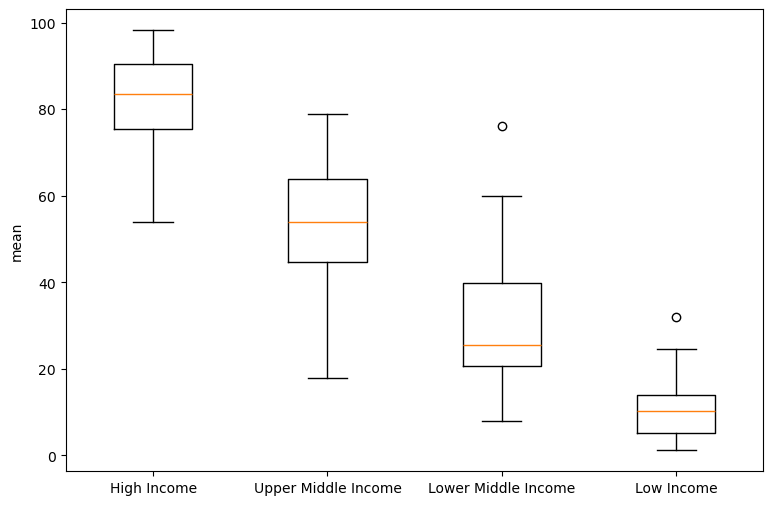

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, tukey_hsd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

wb = pd.read_csv('../data/world-bank.csv')

high_income = wb[(wb['Income group'] == 'High income') & (wb['Year'] == 2016)]
u_middle_income = wb[(wb['Income group'] == 'Upper middle income') & (wb['Year'] == 2016)]
l_middle_income = wb[(wb['Income group'] == 'Lower middle income') & (wb['Year'] == 2016)]
low_income = wb[(wb['Income group'] == 'Low income') & (wb['Year'] == 2016)]

fig, axs = plt.subplots(1, 1, figsize=(9, 6))
axs.boxplot([high_income['Internet'].dropna(), u_middle_income['Internet'].dropna(), l_middle_income['Internet'].dropna(), low_income['Internet'].dropna()])
axs.set_xticklabels(["High Income", "Upper Middle Income", "Lower Middle Income", "Low Income"]) 
axs.set_ylabel("mean") 
plt.show()

Figure 1 illustrates the distribution of Internet usage across income groups. The visualization shows a clear increase in Internet penetration as income level rises.

## Regression Analysis

A linear regression analysis was conducted to examine the relationship between political stability and Internet usage across countries. Political stability is measured using the World Bank's Political Stability and Absence of Violence/Terrorism index, which is normalized as a z-score, where higher values indicate greater political stability and lower values indicate higher levels of instability or conflict. The scatter plot with the fitted regression line illustrates the relationship between these variables. The graph shows a positive trend, indicating that countries with greater political stability tend to have higher levels of Internet penetration. This suggests that stable political environments may support the development of digital infrastructure and broader access to Internet services.

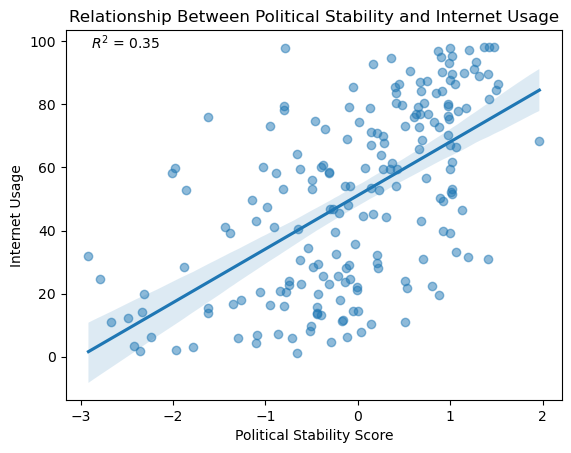

In [5]:
data_2016 = wb[wb['Year'] == 2016]
clean_data = data_2016[['PoliticalStability', 'Internet']].dropna()

X = clean_data['PoliticalStability']
X = sm.add_constant(X)  # adding a constant for the intercept
y = clean_data['Internet']

# Build OLS regression model
est = sm.OLS(y, X)
est = est.fit()

sns.regplot(x='PoliticalStability', y='Internet', data=clean_data, scatter_kws={'alpha':0.5})

plt.xlabel("Political Stability Score")
plt.ylabel("Internet Usage")
plt.title("Relationship Between Political Stability and Internet Usage")
plt.text(0.05, 0.95, f"$R^2$ = {est.rsquared:.2f}", transform=plt.gca().transAxes)

plt.show()

Figure 2 illustrates the relationship between political stability and Internet usage across countries in 2016. The scatter plot with the fitted regression line shows a positive association, indicating that countries with greater political stability tend to have higher levels of Internet penetration.

## Discussion

The results of this analysis suggest that both economic development and political stability are associated with Internet access across countries. The ANOVA analysis revealed significant differences in Internet usage between income groups, with higher-income countries exhibiting substantially greater Internet penetration than lower-income countries. This pattern likely reflects differences in infrastructure investment, technological development, and economic resources. The regression analysis also indicates a positive relationship between political stability and Internet usage, suggesting that more stable political environments may facilitate the expansion of Internet infrastructure and digital services. Together, these findings highlight the importance of both economic and institutional factors in shaping global Internet accessibility. However, Internet access is influenced by many additional factors such as education, urbanization, and government investment, which were not included in this analysis.

## Conclusion

In conclusion, this analysis demonstrates that both economic and political factors are strongly associated with Internet access across countries. The ANOVA results show that Internet usage differs significantly across income groups, with higher-income countries exhibiting substantially greater Internet penetration. The regression analysis also indicates a positive relationship between political stability and Internet usage, suggesting that stable political environments may support the expansion of digital infrastructure. Overall, these findings highlight how both economic development and political stability contribute to global differences in Internet accessibility.